# Explore here

In [22]:
# Librerías

import pandas as pd

df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [23]:
df.shape

(1338, 7)

Podemos ver que nuestro df tiene 1337 filas y 7 columnas, de las cuales 'charges' es nuestra variable objetivo a predecir (Prima del seguro médico a pagar).

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


De las 7 variables, 4 son numéricas y 3 son categóricas.

In [4]:
categoricas = df.select_dtypes(include=['str']).columns.tolist()
categoricas

['sex', 'smoker', 'region']

In [5]:
numericas = df.select_dtypes(exclude=['str']).columns.tolist()
numericas

['age', 'bmi', 'children', 'charges']

In [ ]:
# Antes de hacer las transformaciones de las categóricas es importantes que analicemos si hay filas duplicadas:

df.duplicated().sum()


np.int64(1)

In [ ]:
# Vemos que hay una fila duplicada, entonces utilizamos nuestro código para eliminarlas.

if df.duplicated().sum():
    df.drop_duplicates(inplace= True)

df.shape

(1337, 7)

Vemos que ahora tenemos 1337 filas y antes teníamos 1338. Eliminamos la duplicada correctamente.

In [8]:
# Ahora debemos transformar las variables categóricas en numéricas:

for columna in categoricas:
    df[columna] = pd.factorize(df[columna])[0]

df.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   int64  
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   int64  
 5   region    1337 non-null   int64  
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 83.6 KB


Podemos ver que ahora todas nuestras columnas son numéricas.

Ya tenemos todos nuestros datos numéricos asique podemos hacer ahora una REGRESIÓN LINEAL. 
Una de las cosas que tenemos que hacer para asegurarnos que no haya multicolinealidad y que si hayan relaciones lineales es hacer un heatmap de correlaciones, de esa forma vamos a ver las correlaciones entre las variables independientes y veremos si es factible llevar adelante este modelo, ya que unos de los requisitos es la Ausencia de multicolinealidad entre ellas.

Vamos a hacer nuestra MATRÍZ DE CORRELACIÓN **(este es un paso que tenemos que hacer sí o sí. Si hacemos un EDA tenemos que hacer un análisis univariante para llegar a las mismas conclusiones con cada una de las variables respecto a la que vamos a predecir, pero si hacemos una matriz de correlaciones, saltamos ese paso)**

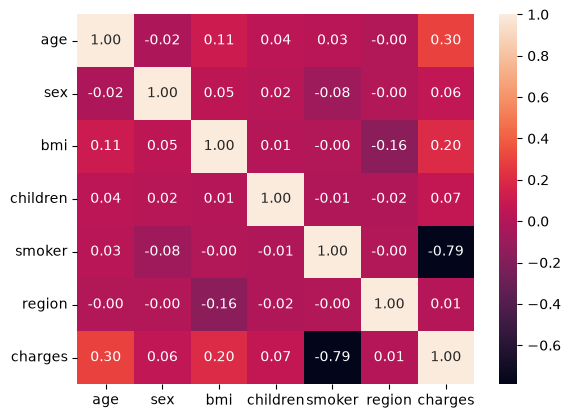

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f'
)

plt.show()

En esta matriz de correlación vemos las correlaciones lineales de las variables entresí y con respecto a los cargos/prima del seguro (variable objetivo). Vemos que las regiones ('region') tienen muy poca correlación lineal, tmb con respecto al número de hijos ('children'), y tmb con respecto al sexo ('sex'). Pero sí hay fuertes correlaciones lineales en la edad ('age'), en el imc ('bmi') y en si es fumador o no ('smoker': -0.79). Entonces deberíamos quedarnos con esas variables con fuerte correlación. Eso respecto de la relación de las variables independientes con la objetivo. 

Con respecto al grado de correlación de las variables independientes entre sí vemos que no hay ninguna que alcance ni supere una correlación mayor al 0.50, por ende no hay multicolinealidad. Podemos avanzar.



In [ ]:
df_var = df[['age', 'bmi', 'smoker', 'charges']]

# Tmb deberíamos chequear que ninguna de estas 4 variables tengan una alta correlación con alguna de las otras variables, ya que si es así, entonces no deberíamos incluirla en nuestro modelo de regresión lineal.

In [11]:
df_var.describe()

,age,bmi,smoker,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,0.795064,13279.121487
std,14.044333,6.100468,0.403806,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,1.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,1.000000,16657.717450
max,64.000000,53.130000,1.000000,63770.428010


Esto es para ver si las variables tiene un máximo y un mínimo muy distinto. Tenemos que el BMI va de un mínimo de 15 a un máximo de 53, la edad un mínimo de 18 a un máximo de 64, smoker se mueve entre 0 y 1, y charges otros importes. 

In [ ]:
# para pasar por un proceso de NORMALIZACIÓN y que sea independiente, tenemos que dividir el dataset en train y test, para que el test no se vea afectado por la normalización del train.

x= df_var.drop(columns=['charges'])
y= df_var['charges']

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y , test_size= 0.20, random_state=42)

x_train.head()

,age,bmi,smoker
1114,23,24.510,1
968,21,25.745,1
599,52,37.525,1
170,63,41.470,1
275,47,26.600,1


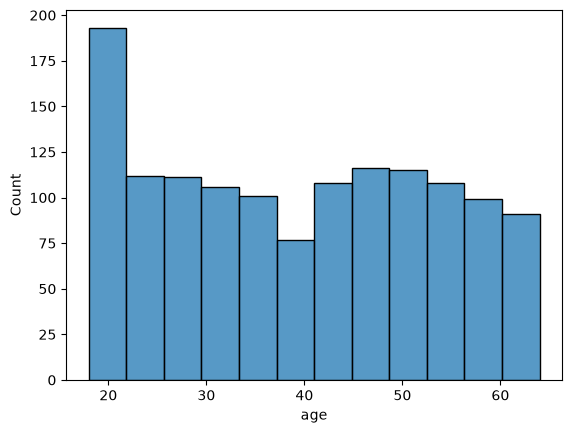

In [13]:
sns.histplot(data= df_var, x= 'age')

plt.show()

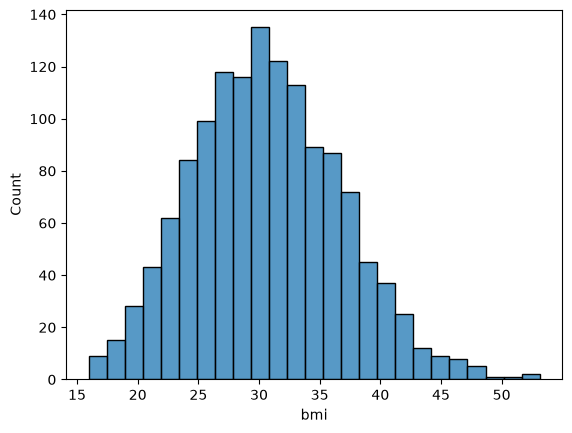

In [14]:
sns.histplot(data= df_var, x= 'bmi')
plt.show()

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler= MinMaxScaler()

x_train_esc = scaler.fit_transform(x_train, y_train)
x_test_esc = scaler.transform(x_test)

x_train_esc = pd.DataFrame(x_train_esc, columns=x_train.columns, index=x_train.index)
x_test_esc = pd.DataFrame(x_test_esc, columns=x_test.columns, index= x_test.index)


In [16]:
# Ya tenemos nuestros x de test y train escalados, con los cuales vamos a poder hacer un mejor modelo. 
# Ya que tenemos los datos preparados y listos para pasarselos a un modelo, vamos al modelo:

from sklearn.linear_model import LinearRegression

model= LinearRegression()
model.fit(x_train_esc, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 11586.3 , 11329.51,-23074.26]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['age','bmi','smoker']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.17e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


Y acá nos muestra los parámetros y los atributos. Tenemos los coeficientes tmb. Una vez que ya tenemos nuestro modelo ajustado, podemos imprimir el interceptor y los coeficientes:

In [17]:
print(f'Intercepto:{model.intercept_}')
print(f'Coeficientes:{model.coef_}')

Intercepto:21701.79391257017
Coeficientes:[ 11586.30415359  11329.51105637 -23074.26173498]


In [18]:
# Para seguir con nuestro modelo tenemos que hacer predicciones:

y_pred = model.predict(x_test_esc)
y_pred

array([ 8433.67443577,  4336.46678013, 13165.0382606 , 30593.69534864,
        8738.64384303, 13004.1887831 , 29273.63576136,  2177.09021482,
       10922.95093736, 10315.83022735, 11021.84491859, 33740.33309282,
       30613.92158231, 18004.87150727,  9656.23179762,  9311.37354392,
        4325.12010919, 32099.96630635,  3001.71338943,  5552.62898392,
        4325.12010919, 29913.00795743, 14580.01800456, 30752.45719245,
       31444.92261851,  4769.02189756, 35187.05259131, 37413.46842278,
       10952.8675722 , 12177.75978526,  6505.9651105 , 13121.95183512,
         870.87899962, 12471.87695664, 40355.37672202, 12499.04467281,
        2732.11267963,  2866.20850841, 32023.18474965,  9365.1280589 ,
        6903.0538664 , 29243.81679061, 34097.79751626, 11919.91981386,
        6896.22734444,  4145.55111435,  6040.33037213,  9173.38425823,
        4186.69945959,  8909.59778913,  6340.1295272 , 12053.6361681 ,
       30836.41015271,  4425.70495311, 10719.84316929,  9666.05445578,
      

In [19]:
from sklearn.metrics import root_mean_squared_error, r2_score

print(f'RMSE:{root_mean_squared_error(y_test, y_pred)}')
print(f'R2:{r2_score(y_test, y_pred)}')

RMSE:5986.783344847845
R2:0.8049502474643171


**El RMSE nos da una idea de que tan lejos están nuestras predicciones de los valores reales, mientras que el R2 nos da una idea de que tan bien se ajusta nuestro modelo a los datos.**

Acá podemos ver qué tan bueno es nuestro modelo, y vemos que se equivoca aproximadamente en 6 mil, y tenemos un R2 del 80%. Con correlaciones más altas, tendríamos un mejor RMSE y R2. Eran un poquito bajas las correlaciones en este caso para este modelo, pero no teníamos más. 
